# Iris â€” exploration for Lab 1 (k-NN Classification)

Purely exploratory: helps justify what we already observed running the C++ `KNNClassifier` in the app (Tasks 1-4). Doesn't replace the C++ implementation â€” `scikit-learn` here is only a fast reference to sanity-check our own results and sweep `k` values we can't easily automate by hand in the UI.

Questions we want to answer:
- Why does every confusion matrix we got show zero errors for Class 1 and all errors between Class 2/3? (Task 1-3 discussion)
- What's a good range for `k`, and where does it break down? (Task 4)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

sns.set_theme(style="whitegrid")

df = pd.read_csv("../Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 1. Sanity check

Same checks the C++ `DataLoader`/`DataPreprocessor` are doing implicitly â€” confirm no missing values, confirm the class balance matches the lab statement (150 rows, 50 per class).

In [2]:
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())
print("\nClass balance:\n", df["Species"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None

Missing values per column:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class balance:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 2. Why is Class 1 (Setosa) always perfectly classified?

A pairplot colored by species â€” look for which species overlaps with which.

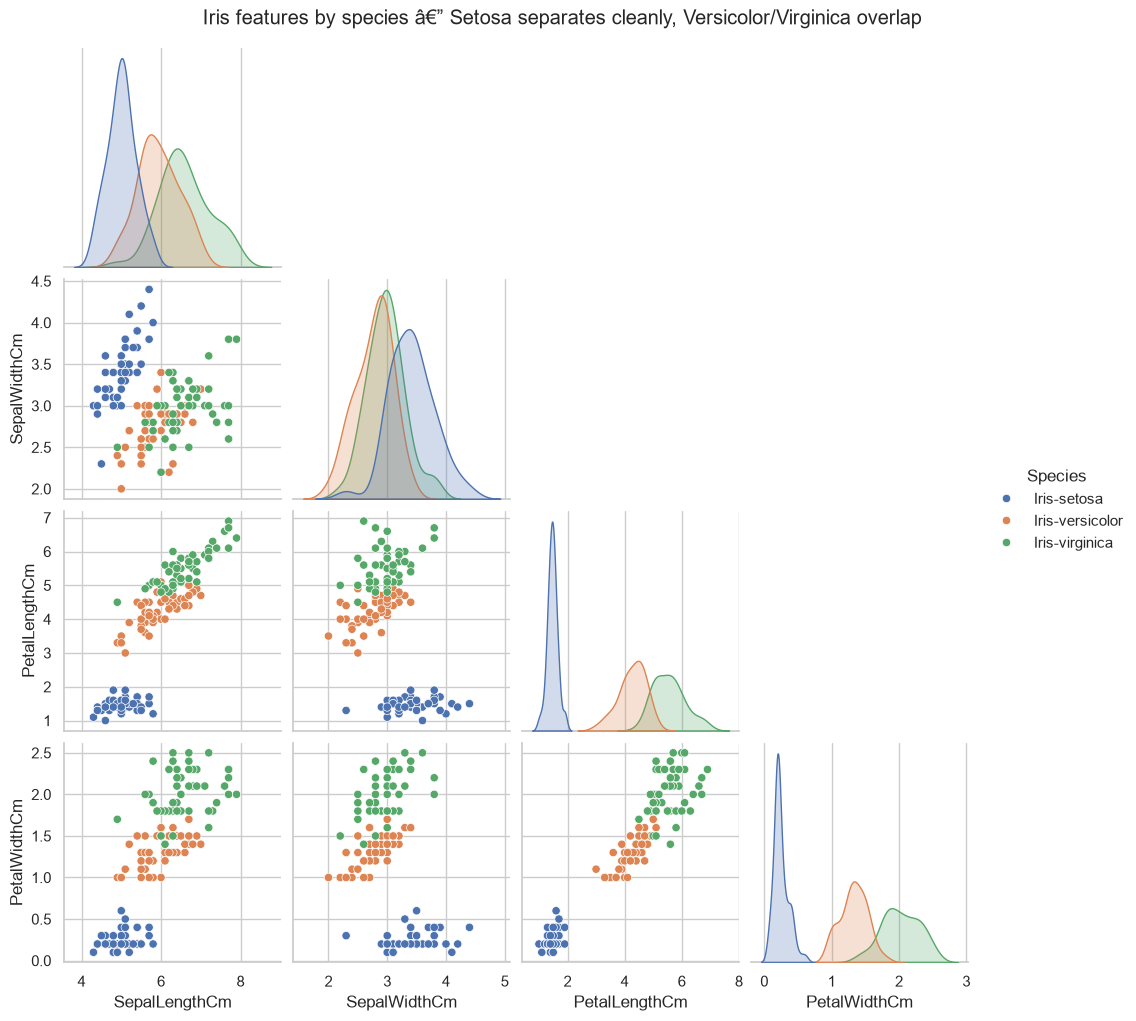

In [3]:
feature_cols = [c for c in df.columns if c not in ("Id", "Species")]
sns.pairplot(df, hue="Species", vars=feature_cols, corner=True)
plt.suptitle("Iris features by species â€” Setosa separates cleanly, Versicolor/Virginica overlap", y=1.02)
plt.show()

**Expected takeaway**: Setosa forms a visually distinct cluster on every feature pair involving petal length/width â€” this is exactly why every confusion matrix from the C++ app (any `k`) shows zero errors on Class 1. Versicolor and Virginica overlap, especially on sepal measurements â€” that overlap is the source of every misclassification observed, regardless of `k`.

## 3. Feature correlation with the class label

Matches the lab PDF's own summary statistics table (petal length/width have the highest class correlation) â€” confirms it visually instead of taking it on faith.

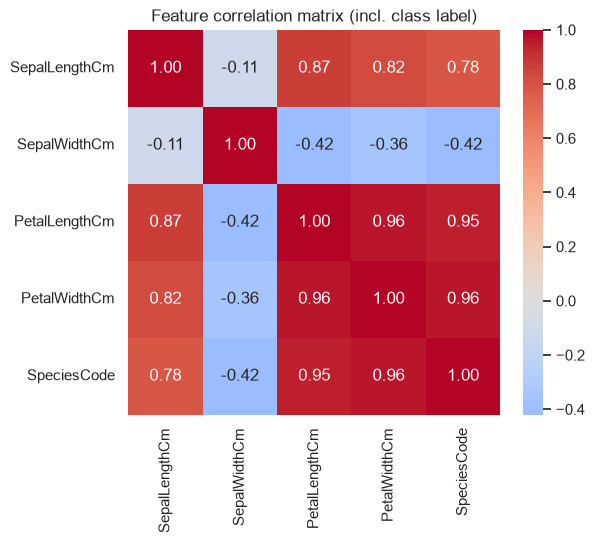

In [4]:
df_numeric = df.copy()
df_numeric["SpeciesCode"] = df_numeric["Species"].astype("category").cat.codes
corr = df_numeric[[*feature_cols, "SpeciesCode"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix (incl. class label)")
plt.show()

## 4. Sweeping `k` â€” Task 4

Same 80/20 split logic as the C++ app. We sweep far more `k` values than we could manually click through in the UI, to see the full accuracy curve and answer "what's the largest/smallest useful `k`" with actual numbers instead of a handful of manual runs.

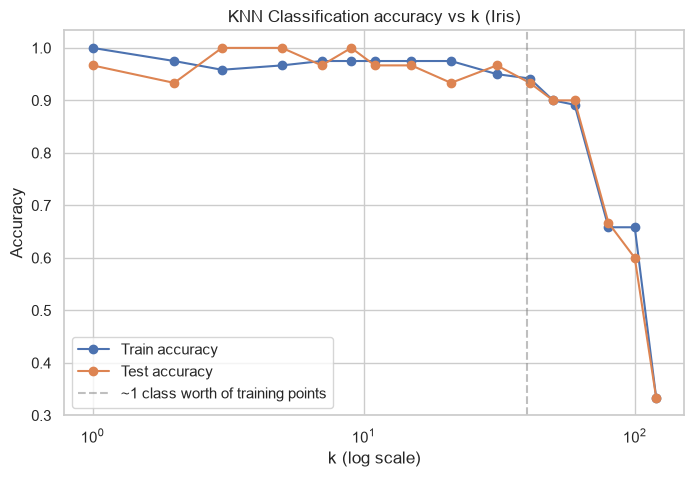

,k,train_acc,test_acc
0,1,1.000000,0.966667
1,2,0.975000,0.933333
2,3,0.958333,1.000000
3,5,0.966667,1.000000
4,7,0.975000,0.966667
5,9,0.975000,1.000000
6,11,0.975000,0.966667
7,15,0.975000,0.966667
8,21,0.975000,0.933333
9,31,0.950000,0.966667


In [5]:
X = df[feature_cols].to_numpy()
y = df["Species"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

k_values = [1, 2, 3, 5, 7, 9, 11, 15, 21, 31, 41, 50, 60, 80, 100, len(X_train)]
train_acc, test_acc = [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_acc, marker="o", label="Train accuracy")
plt.plot(k_values, test_acc, marker="o", label="Test accuracy")
plt.axvline(len(X_train) // 3, color="gray", linestyle="--", alpha=0.5, label="~1 class worth of training points")
plt.xscale("log")
plt.xlabel("k (log scale)")
plt.ylabel("Accuracy")
plt.title("KNN Classification accuracy vs k (Iris)")
plt.legend()
plt.show()

pd.DataFrame({"k": k_values, "train_acc": train_acc, "test_acc": test_acc})

**For the Task 4 discussion**: note where test accuracy peaks, and where it starts dropping once `k` approaches/exceeds the ~40 training points of a single class â€” same effect we already saw manually in the C++ app at `k=50` (train dropped to 90%, test to 87%).